# MicroCT Multiscale Rock Physics modeling

In this notebook, we will estimate the basics of petrophysics properties (Porosity, permeability, clay volume, water saturation, etc.).

With the pyrockphys package we can apply all the basics petrophysics process using the BPOperator.






## Introduction
This workbook aims to employ microCT results about the detected porosity and its geometrical characteristics, such as aspect ratio, to input information for Rock Physics modeling purposes based on inclusion theory, fitting rock properties related to the texture and elastic moduli response from laboratory or well logs (multiscale input data). 

## Data set
The data set for this study focuses on Well 1-BRSA-1045-SPS (pre-salt carbonates).
The Digital Image Analysis was done using microCT of 5 samples, considering the characteristics:
- Petrophysics and mineralogy measurements & information: porosity, density, mineral phases, etc.;
- Ultrasonic P- and S-wave velocities: ambient and under confining pressure, dry, saturated conditions, etc.;
- PUC-RS SkyScan CT of standard samples ~38 mm in diameter – voxel res. 12.14 µm;
- MOGNO CT beamline (CNPEM/LNLS/Sirius), 2 resolutions are available:
    - Specimen ~6 mm in diam.: voxel res. 3.33 µm;
    - Specimen ~2.5 mm in diam.: voxel res. 1.27 µm.

In summary, the pore system was identified and pores isolated, aiming to compute geometrical properties by ellipsoid fits (radius, diameter, area, aspect ratio, etc.). Thereafter, all results were combined to quantify pore occurrence by the image resolution and contribution, as shown in Figure 1. 

![MicroCT input resolutions](./MicroCT_Utility/Figures/Fig_microCT_resolution_of_pores_from_3_resolutions.png)
Figure 1 - Summary of pore contribution from each microCT resolution, focusing on the pore area occurrence. 

## Pore occurrence as inclusions
The micropores are assumed to be lower than 500 µm² (Anselmetti et al., 1998), as highlighted in the dashed red line in Figure 1. Thus, we can account the pore occurrence considering the pore inclusion types for modeling. The Figure 2 shows a summary of the pore occurrence results for each microCT resoltution and contribution for porosity.   
In this workbook, we can state at least 3 pore types inclusions by the suppositions:
- The macropores are expressed as follows to the maximum observed pore area, especially from CT results of standard samples (~38 mm in diam.),  which the mean aspect ratio is assumed to be representative from PUC-RS SkyScan CT.
- The mesopores are assumed onto the observed overlap porosity from all image resolutions, which the mean aspect ratio is assumed to be representative from MOGNO CT results of specimen ~6 mm in diameter.
- The microporosity is the critical inclusion, because image porosity results are lower to the Helium gas laboratory porosity, and a very low part is supposed to be detectable at best MOGNO CT resolution (see Figure 2-A), justifying an aspect ratio calibration by the modeling in methodology. 

Figure 3 shows the mean aspect ratio distribution for samples from microCT analysis. As discussed for the pore aspect ratio, the input values of the macropores are assumed from "Reference" and mesopores from "Part 1" results.

![MicroCT Pore Contribution from 3 CT Resolutions](./MicroCT_Utility/Figures/Fig_microCT_pore_areas_occurrence.png)
Figure 2 - Summary of the pore contribution for the total image porosity for each microCT resolution: A) Porosity contribution, and B) Total pore occurrence.

![MicroCT mean pore aspect ratio](./MicroCT_Utility/Figures/Fig_mean_aspect_ratio_microCT_scales.png)
Figure 3 - The mean aspect ratio distribution for samples from microCT analysis: macropores are assumed from "Reference" and mesopores from "Part 1" results.

## Methodology
The methodology (Figure 4) assumes that meso- and macropores are detectable from microCT, and their mean aspect ratios are reliable for Rock Physics inclusion modeling of Carbonates. However, a representative aspect ratio of micropores should be predicted. Thus, the idea is to perform a "Multiscale Rock Physics modeling", using input data from laboratory or NMR well (e.g.) about the porosity occurrence, P-wave velocity (Vp), and density of rock in reference, and its mineralogy properties (bulk and shear moduli, and density) for a dry condition. 

The inclusions can be modeled by setting the ideal Rock Physics inclusion model (e.g., DEM - Differential Effective Medium), and the calculated Vp from the model results of elastic moduli can be compared with the Vp-reference, ensuring a minimum error in the prediction of micropore aspect ratio. 

The S-wave velocity (Vs) can be computed using the final shear modulus after method calibration and compared with measurements (if available) or employed for prediction. In addition, the calibrated inclusions of micro-, meso-, and macropores can be applied to similar textures, involving the modeling of elastic velocities or correlated properties using laboratory or well log data.   

![MicroCT Multiscale Flowchart](./MicroCT_Utility/Figures/Fig_methodology_flowchart_Equinor.png)

Figure 4 - Methodology for multiscale Rock Physics modeling, using input data from laboratory or NMR well (e.g.), especially about porosity occurrence, and invert the micropore aspect ratio by choosing an inclusion approach, and considering texture control of input properties.

## Python modeling & tests

The method in Figure 4 is automated by a developed Python library that accepts a list of many inclusions.
In this workbook, we will make a test using 3 inclusions (macro, meso, and micropores), considering well log input properties at depth of the 5 samples and input aspect ratios for macro and mesopores estimated from microCT. 
The modeling method allow us to set an inclusion Rock Physics model, choosen DEM (Differential Effective Medium) for tests.


In [2]:
import pandas as pd
import numpy as np

#Importing auxiliary lib functions in the MicroCT_Utility folder
import sys
import os
current_directory = os.getcwd()
module_directory = os.path.join(current_directory,'MicroCT_Utility')
sys.path.insert(0, module_directory)
import aspect_ratio_Image_dem_multiscale as arinc # To call the method in Fig. 4

#Importing pyrockphys
import pyrockphys # To input data for modeling


Test #1: Applying directly a laboratory input data of the sample F7289H trying to test the imported library about the flowchart in Figure 4.

In [3]:
# Temporary test (1 amostra, dados extraídos da tabela laboratório em Utility/Input_data)
# A ideia seria usar dados de entrada do poço no fluxo Fig 4, para a profundidade de cada uma das 5 amostras (na planilha). 
# Dados de mineralogia do perfil correspondente (filtrado)...
# Dados de volume de poros do NMR: macro, meso, micro (total 1)
# O único dado de tomografia seria a razão de aspecto macro e meso na planilha. 
# Daí, inverter a razão de aspecto microporo.
#F7289H
vp_m = 5.087
k1 = 68.00
mu1 = 32.58
ro1 = 2.719
phi = 0.1242 # Porosidade total em fração (v/v)

# Dry (air)
k2 = 0.000131
mu2 = 0.0
ro2 = 0.00119

# Known inclusions (volume faction and aspect ratio) - [macro, meso]
frac_inc_known = [0.16, 0.6211]
asp_inc_known = [0.56, 0.58]

# Micropore fraction -> target of pore aspect ratio inversion
fmic = 1-sum(frac_inc_known)
#fmic = sample['Micropores occurrence (0-1)'] 
 
# Calling method
vpa_out, vsa_out, rho_out, aspmic_out, fit_out = arinc.aspect_ratio_Image_dem_multiscale(
    vp_m, k1, mu1, ro1, k2, mu2, ro2, phi, 
    frac_inc_known, asp_inc_known, fmic
)
# Impressão dos resultados
print("-" * 50)
print("RESULTADOS DA INVERSÃO DEM MULTISCALE (Versão Unificada)")
print("-" * 50)
print(f"Vp Medida: {vp_m:.4f} km/s")
print(f"Razão de Aspecto Invertida (P3 - aspmic): {aspmic_out:.4f}")
print(f"Vp Calculada (Vp_a): {vpa_out:.4f} km/s")
print(f"Taxa de Ajuste (fit): {fit_out * 100:.2f}%")
print("-" * 50)

--------------------------------------------------
RESULTADOS DA INVERSÃO DEM MULTISCALE (Versão Unificada)
--------------------------------------------------
Vp Medida: 5.0870 km/s
Razão de Aspecto Invertida (P3 - aspmic): 0.0500
Vp Calculada (Vp_a): 5.0841 km/s
Taxa de Ajuste (fit): 99.94%
--------------------------------------------------


Test #2: Extracting LAS input data of the sample F7289H in depth (5055.1 m) trying to test the imported library about the flowchart in Figure 4.

In [4]:
input_file = './MicroCT_Utility/Input_data/input_multiscale_lab_data_dry_22MPa_BRSA_1045.xlsx'
lab1045 = pd.read_excel(input_file)
print ("Lab data set: ")
print (lab1045.head())


#Loading las file
log1045 = pyrockphys.datacontainers.LogArray()
log1045.logLoad('../../Dataset/1-BRSA-1045-SPS/1-BRSA-1045-SPS-MN-FC.las')

Lab data set: 
   Sample  Vp (km/s)  Vs (km/s)  Kmin (GPa)  Gmin (GPa)  Rhomin (g/cc)  \
0  F7289H      5.087      2.844   68.000070   32.581908       2.719211   
1  F7292H      5.237      2.686   61.843157   35.769044       2.718716   
2  F7293H      5.077      2.973   57.569288   37.559930       2.712935   
3  F7294H      5.113      2.868   67.370814   35.690611       2.737874   
4  F7296H      5.650      3.044   72.423177   36.005470       2.756348   

     Phi (%)  Phi (v/v)  Kfl (GPa)  Rhofl (g/cc)  Macropores occurrence (0-1)  \
0  12.419154   0.124192   0.000131       0.00119                         0.16   
1  15.525511   0.155255   0.000131       0.00119                         0.27   
2  12.083608   0.120836   0.000131       0.00119                         0.21   
3  16.509234   0.165092   0.000131       0.00119                         0.18   
4   9.973006   0.099730   0.000131       0.00119                         0.25   

   Macropores aspect ratio  Mesopores occurrence (0-1

In [5]:
#Creating a RockLog
rock1045 = pyrockphys.datacontainers.RockLog()
rock1045.fromLogarray(log1045)

RockLog from LogArray builded!


In [6]:
basicspetrophysics = pyrockphys.Rockphysics.Basics.BPOperator(log1045, rock1045)
basicspetrophysics

AttributeError: module 'pyrockphys' has no attribute 'Rockphysics'

In [7]:
plotting = pyrockphys.Visualization.Plotting()

AttributeError: module 'pyrockphys' has no attribute 'Visualization'

### Porosity Estimation

In [8]:
basicspetrophysics.estimateProperty('porosity')

NameError: name 'basicspetrophysics' is not defined

In [9]:
basicspetrophysics.run(model='density', rholog='RHOZ', saturation='SW', rhobrine=1.1, rhograin=2.7, rhohc=0.89)

NameError: name 'basicspetrophysics' is not defined

In [ ]:
basicspetrophysics.run(model='sonic', dtlog='DTCO', saturation='SW', dtbrine=210, dtgrain=45, dthc=189)

Executing Algo .....
Estimating porosity using SONIC Model!
SONIC Porosity Estimated!


In [ ]:
basicspetrophysics.run(model='Neutron', dphilog='DPHI', nlog='TNPH_FILT_DPK')

Executing Algo .....
Estimating porosity using NEUTRON Model!
NEUTRON Porosity Estimated!


In [ ]:
basicspetrophysics

Log: 1-BRSA-1045-SPS 
RockLog Data: ['DPHI', 'SPHI', 'NDPHI']

### Pore Structure

In [ ]:
basicspetrophysics.estimateProperty('pore structure')

Pore Structure estimation using NMR Equations: 
(Clay Bound Water (CBW), Bound Fluid Volume (BFV) 
Free Fluid Index (FFI), Effective Porosity (PHIE) 
Total Porosity (PHIT), Micro, Meso, and Macro porosity).

In [ ]:
basicspetrophysics.run(BP=['CBP1', 'CBP2', 'CBP3', 'CBP4', 'CBP5', 'CBP6', 'CBP7', 'CBP8'])

Executing Algo .....
Estimating Pore Structure using NMR Equations!
NMR Pore Structure Estimated!


In [ ]:
basicspetrophysics

Log: 1-BRSA-1045-SPS 
RockLog Data: ['DPHI', 'SPHI', 'NDPHI', 'GRI', 'LAR', 'LART', 'CLAVIER', 'STIEBER', 'VCLAY_FINE', 'VCLAY_RAD', 'CBW', 'BFV', 'FFI', 'PHIE', 'PHIT', 'MICROPORE', 'MESOPORE', 'MACROPORE']

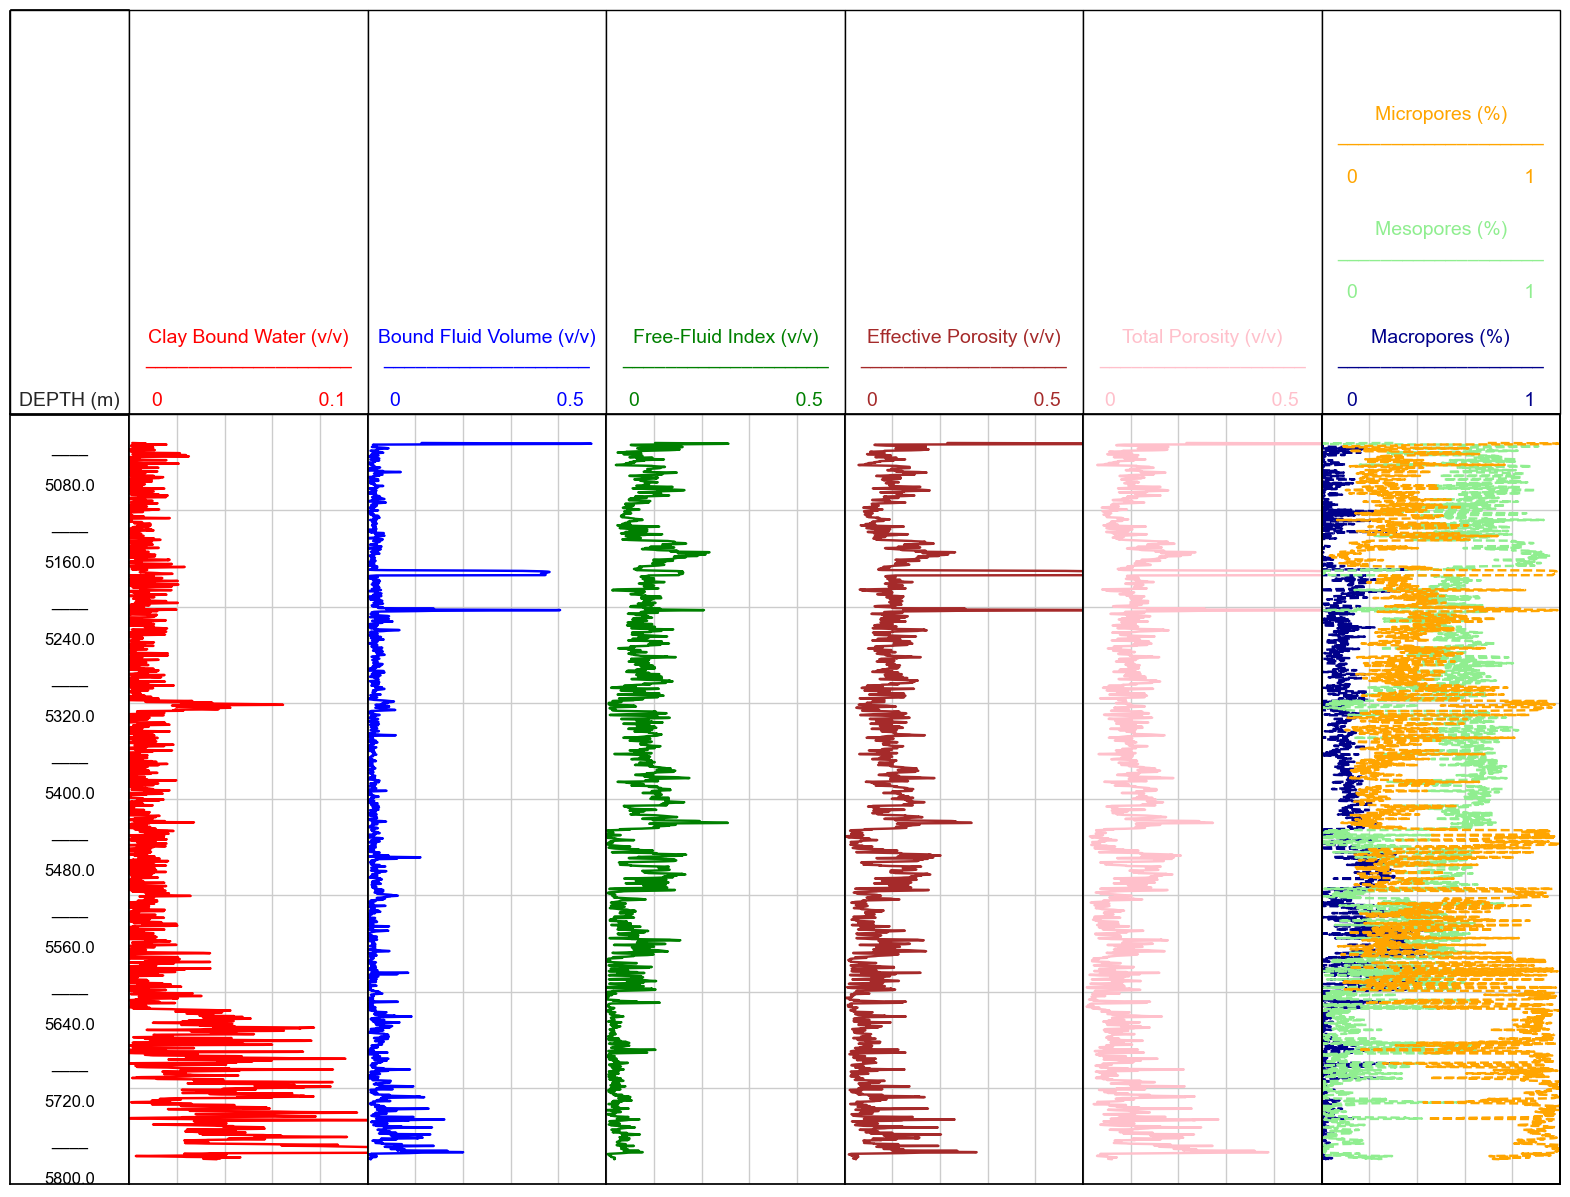

In [ ]:
plot1 = ['log', rock1045.attr['CBW'], rock1045.attr.index.values, 'red', 1, [0, 0.1], 'line', 'Clay Bound Water (v/v)', '-']
plot2 = ['log', rock1045.attr['BFV'], rock1045.attr.index.values, 'blue', 2, [0, 0.5], 'line', 'Bound Fluid Volume (v/v)', '-']
plot3 = ['log', rock1045.attr['FFI'], rock1045.attr.index.values, 'green', 3, [0, 0.5], 'line', 'Free-Fluid Index (v/v)', '-']
plot4 = ['log', rock1045.attr['PHIE'], rock1045.attr.index.values, 'brown', 4, [0, 0.5], 'line', 'Effective Porosity (v/v)', '-']
plot5 = ['log', rock1045.attr['PHIT'], rock1045.attr.index.values, 'pink', 5, [0, 0.5], 'line', 'Total Porosity (v/v)', '-']
plot6 = ['log', rock1045.attr['MACROPORE'], rock1045.attr.index.values, 'darkblue', 6, [0, 1], 'line', 'Macropores (%)', '--']
plot7 = ['log', rock1045.attr['MESOPORE'], rock1045.attr.index.values, 'lightgreen', 6, [0, 1], 'line', 'Mesopores (%)', '--']
plot8 = ['log', rock1045.attr['MICROPORE'], rock1045.attr.index.values, 'orange', 6, [0, 1], 'line', 'Micropores (%)', '--']

plots = [plot1, plot2, plot3, plot4, plot5, plot6, plot7, plot8]

plotting.logView(plots, 7, (20, 10), 14, [5000, 5800])

### Elastic Properties

In [ ]:
basicspetrophysics.estimateProperty('Elastic Templates')

Available Lithologies for elastic templates estimation: , Shale, Sandstone, Dolomite, and Limestone.

In [ ]:
basicspetrophysics.run(lithology='', dtlog='DTCO', dtslog='DTSH5', rholog='RHOZ')

Executing Algo .....
Estimating Rock Physics  Templates!
 Rock Physics Template Estimated!


In [ ]:
basicspetrophysics.run(lithology='Shale', dtlog='DTCO', dtslog='DTSH5', rholog='RHOZ')

Executing Algo .....
Estimating Rock Physics Shale Templates!
Shale Rock Physics Template Estimated!


In [ ]:
basicspetrophysics.run(lithology='Sandstone', dtlog='DTCO', dtslog='DTSH5', rholog='RHOZ')

Executing Algo .....
Estimating Rock Physics Sandstone Templates!
Sandstone Rock Physics Template Estimated!


In [ ]:
basicspetrophysics.run(lithology='Dolomite', dtlog='DTCO', dtslog='DTSH5', rholog='RHOZ')

Executing Algo .....
Estimating Rock Physics Dolomite Templates!
Dolomite Rock Physics Template Estimated!


In [ ]:
basicspetrophysics.run(lithology='Limestone', dtlog='DTCO', dtslog='DTSH5', rholog='RHOZ')

Executing Algo .....
Estimating Rock Physics Limestone Templates!
Limestone Rock Physics Template Estimated!


In [ ]:
basicspetrophysics

Log: 1-BRSA-1045-SPS 
RockLog Data: ['DPHI', 'SPHI', 'NDPHI', 'GRI', 'LAR', 'LART', 'CLAVIER', 'STIEBER', 'VCLAY_FINE', 'VCLAY_RAD', 'CBW', 'BFV', 'FFI', 'PHIE', 'PHIT', 'MICROPORE', 'MESOPORE', 'MACROPORE', 'ARCHIE', 'SIMANDOUX', 'SWIRR', 'Phiwt', 'PhiH', 'KTIMC', 'KSDR', 'vp', 'vs', 'vpvs', 'Ip', 'Is', 'poi', 'mr', 'lr', 'kr', 'G', 'Ksat', 'lm_ratio', 'lm_dif', 'km_dif', 'IpIs', 'vp_line', 'vs_sh', 'den_sh', 'vpvs_sh', 'Ip_sh', 'Is_sh', 'poi_sh', 'mr_sh', 'lr_sh', 'kr_sh', 'lm_ratio_sh', 'lm_dif_sh', 'km_dif_sh', 'IpIs_sh', 'vs_ss', 'den_ss', 'vpvs_ss', 'Ip_ss', 'Is_ss', 'poi_ss', 'mr_ss', 'lr_ss', 'kr_ss', 'lm_ratio_ss', 'lm_dif_ss', 'km_dif_ss', 'IpIs_ss', 'vs_dol', 'den_dol', 'vpvs_dol', 'poi_dol', 'kr_dol', 'mr_dol', 'lr_dol', 'lm_ratio_dol', 'lm_dif_dol', 'km_dif_dol', 'Ip_dol', 'Is_dol', 'IpIs_dol', 'vs_lime', 'den_lime', 'vpvs_lime', 'poi_lime', 'kr_lime', 'mr_lime', 'lr_lime', 'lm_ratio_lime', 'lm_dif_lime', 'km_dif_lime', 'Ip_lime', 'Is_lime', 'IpIs_lime']

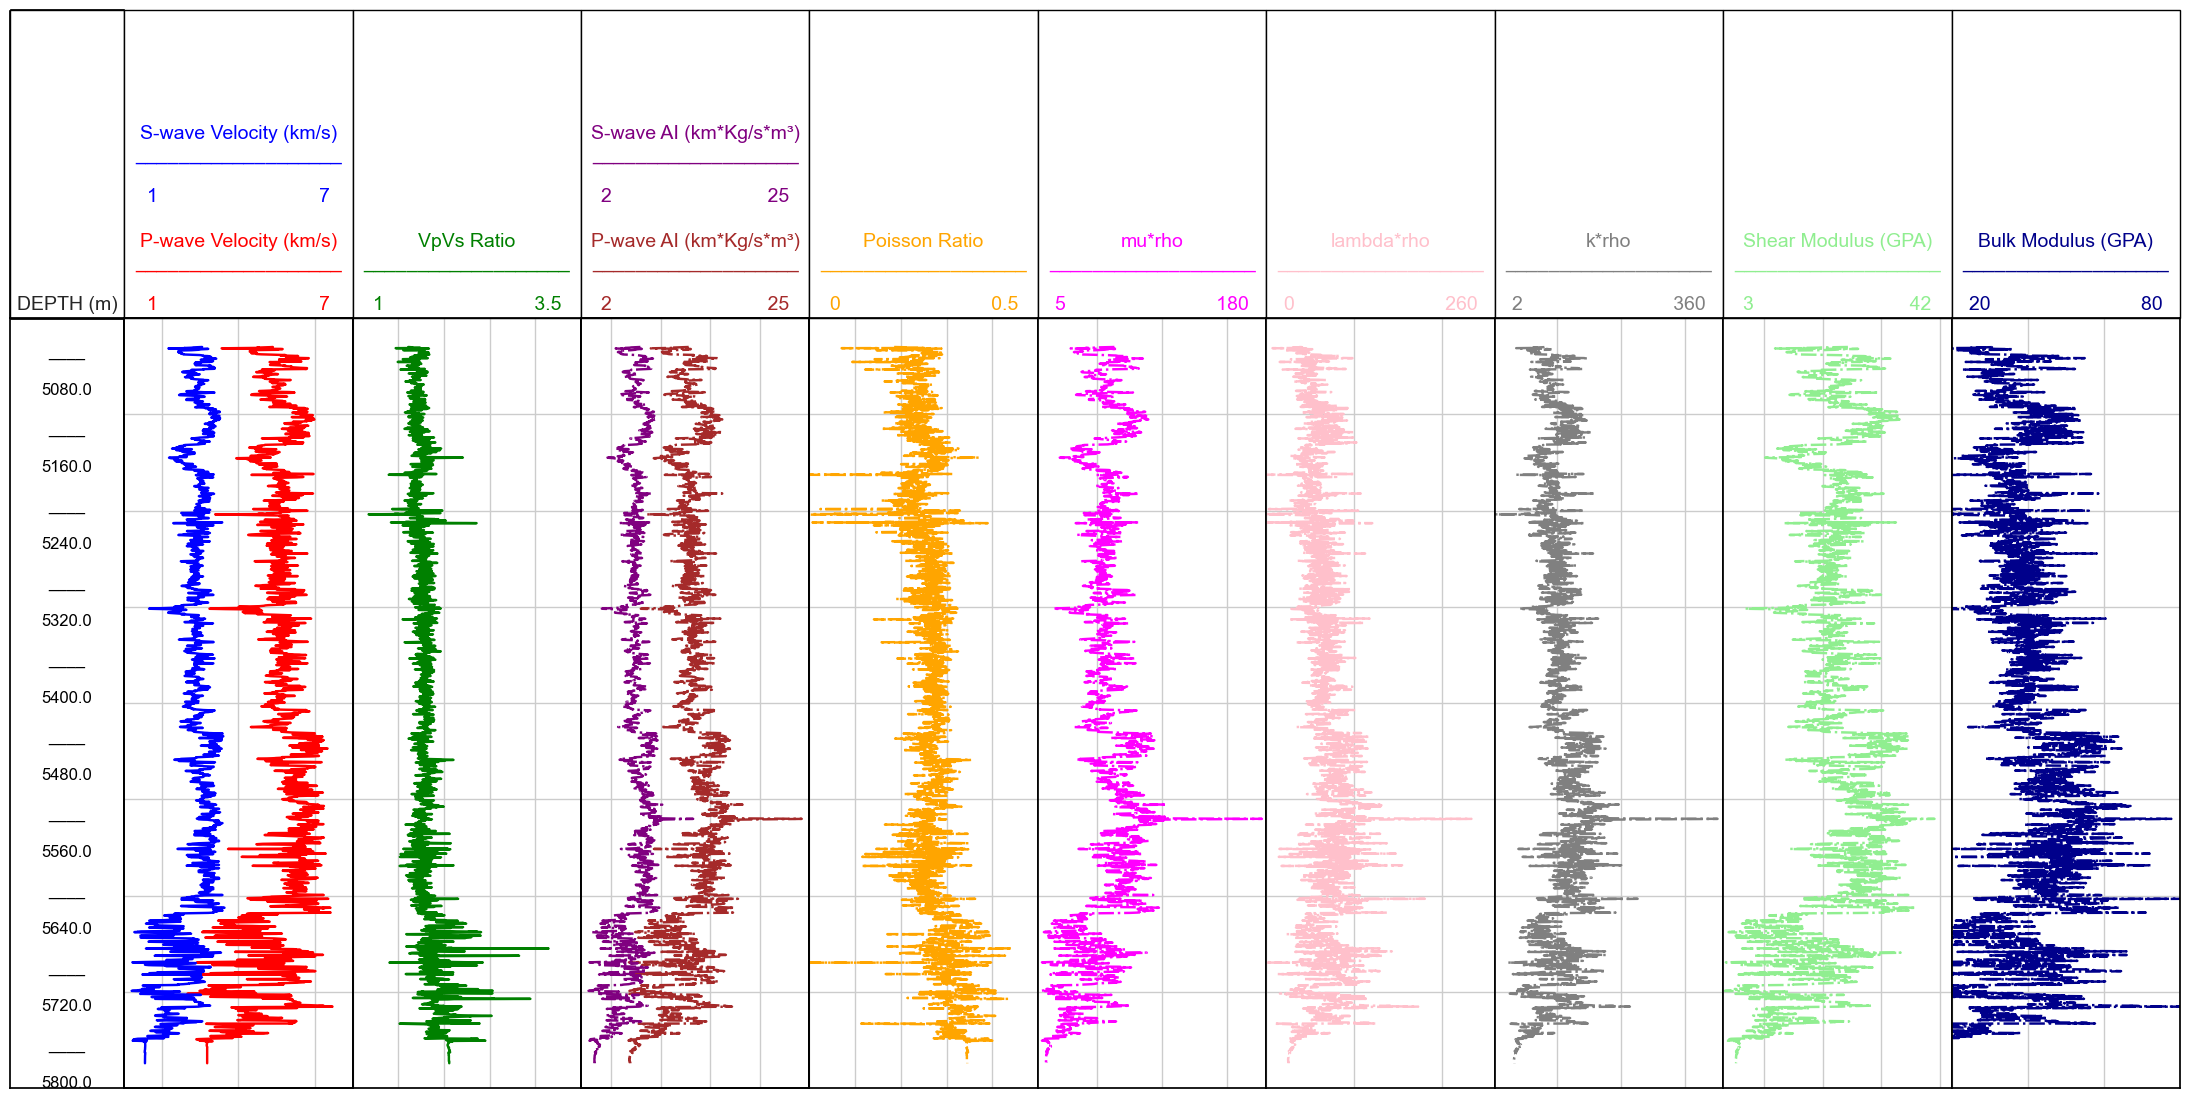

In [ ]:
plot1 = ['log', rock1045.attr['vp'], rock1045.attr.index.values, 'red', 1, [1, 7], 'line', 'P-wave Velocity (km/s)', '-']
plot2 = ['log', rock1045.attr['vs'], rock1045.attr.index.values, 'blue', 1, [1, 7], 'line', 'S-wave Velocity (km/s)', '-']
plot3 = ['log', rock1045.attr['vpvs'], rock1045.attr.index.values, 'green', 2, [1, 3.5], 'line', 'VpVs Ratio', '-']
plot4 = ['log', rock1045.attr['Ip'], rock1045.attr.index.values, 'brown', 3, [2, 25], 'line', 'P-wave AI (km*Kg/s*m³)', '-.']
plot5 = ['log', rock1045.attr['Is'], rock1045.attr.index.values, 'purple', 3, [2, 25], 'line', 'S-wave AI (km*Kg/s*m³)', '-.']
plot6 = ['log', rock1045.attr['poi'], rock1045.attr.index.values, 'orange', 4, [0, 0.5], 'line', 'Poisson Ratio', '-.']
plot7 = ['log', rock1045.attr['mr'], rock1045.attr.index.values, 'magenta', 5, [5, 180], 'line', 'mu*rho', '-.']
plot8 = ['log', rock1045.attr['lr'], rock1045.attr.index.values, 'pink', 6, [0, 260], 'line', 'lambda*rho', '-.']
plot9 = ['log', rock1045.attr['kr'], rock1045.attr.index.values, 'gray', 7, [2, 360], 'line', 'k*rho', '-.']
plot10 = ['log', rock1045.attr['G'], rock1045.attr.index.values, 'lightgreen', 8, [3, 42], 'line', 'Shear Modulus (GPA)', '-.']
plot11 = ['log', rock1045.attr['Ksat'], rock1045.attr.index.values, 'darkblue', 9, [20, 80], 'line', 'Bulk Modulus (GPA)', '-.']

plots = [plot1, plot2, plot3, plot4, plot5, plot6, plot7, plot8, plot9, plot10, plot11]

plotting.logView(plots, 10, (28, 10), 14, [5000, 5800])

### Pressure Estimation

To calculate the pressure data we have to load the full las file (1-BRSA-1045-SPS-IMP), since we have to calculate the pressure variation for the full range of the well.

In [ ]:
#Loading las file
log1045full = pyrockphys.datacontainers.LogArray()
log1045full.logLoad('../../Dataset/1-BRSA-1045-SPS/1-BRSA-1045-SPS-IMP.las')

Log data Loaded!


In [ ]:
#Crating a RockLog
rock1045pressure = pyrockphys.datacontainers.RockLog()
rock1045pressure.fromLogarray(log1045full)

RockLog from LogArray builded!


In [ ]:
basicspetrophysics = pyrockphys.Rockphysics.Basics.BPOperator(log1045full, rock1045pressure)
basicspetrophysics

Log: 1-BRSA-1045-SPS 
RockLog Data: []

In [ ]:
basicspetrophysics.estimateProperty('Pressure')

Calculate overburden, pore, and differential pressure.

In [ ]:
basicspetrophysics.run(mode='Overburden', rholog='RHOZ', tvdss='TVDSS')

Executing Algo .....
Estimating OVERBURDEN pressure!
OVERBURDEN Pressure Estimated!


In [ ]:
import pandas as pd
formationtest = pd.read_excel('../../Dataset/1-BRSA-1045-SPS/formation test.xlsx')
formationtest

,Pressure,Depth
0,55.446799,5033.8
1,55.446799,5033.8
2,55.427186,5034.1
3,55.456606,5034.9
4,55.456606,5034.9
...,...,...
61,58.908547,5368.6
62,59.300813,5403.0
63,59.536172,5424.7
64,59.928438,5458.1


In [ ]:
basicspetrophysics.run(mode='Pore', rholog='RHOZ', tvdss='TVDSS', formationtest_depth=formationtest['Depth'], formationtest_pressure=formationtest['Pressure'])

Executing Algo .....
Estimating PORE pressure!
PORE Pressure Estimated!


In [ ]:
basicspetrophysics.run(mode='Differential', overburden='PO', pore='PP')

Executing Algo .....
Estimating DIFFERENTIAL pressure!
DIFFERENTIAL Pressure Estimated!


In [ ]:
basicspetrophysics

Log: 1-BRSA-1045-SPS 
RockLog Data: ['PO', 'PP', 'PD']

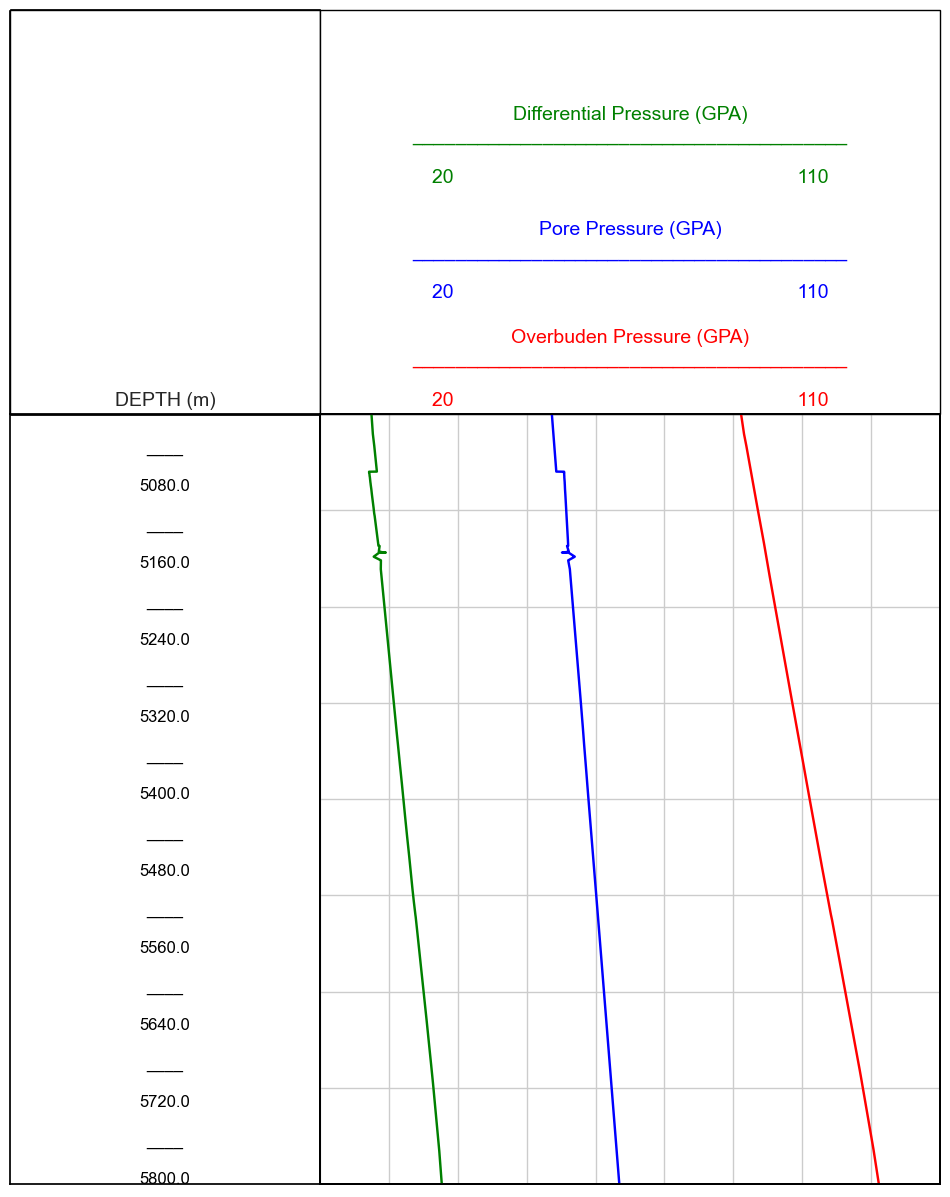

In [ ]:
plot1 = ['log', rock1045pressure.attr['PO'], rock1045pressure.attr.index.values, 'red', 1, [20, 110], 'line', 'Overbuden Pressure (GPA)', '-']
plot2 = ['log', rock1045pressure.attr['PP'], rock1045pressure.attr.index.values, 'blue', 1, [20, 110], 'line', 'Pore Pressure (GPA)', '-']
plot3 = ['log', rock1045pressure.attr['PD'], rock1045pressure.attr.index.values, 'green', 1, [20, 110], 'line', 'Differential Pressure (GPA)', '-']


plots = [plot1, plot2, plot3]

plotting.logView(plots, 2, (12, 10), 14, [5000, 5800])

Now we make a merge to the first RockLog

In [ ]:
rock1045pressure.attr = rock1045pressure.attr[rock1045pressure.attr.index >= 5030]
rock1045pressure.attr = rock1045pressure.attr[rock1045pressure.attr.index <= 5774.13]
rock1045pressure.attr

,PO,PP,PD
MD,,,
5030.1144,81.815555,53.980362,27.835193
5030.2668,81.819419,53.982005,27.837414
5030.4192,81.823232,53.983649,27.839583
5030.5716,81.826984,53.985292,27.841692
5030.7240,81.830711,53.986936,27.843776
...,...,...,...
5773.3692,100.541722,63.149804,37.391918
5773.5216,100.544989,63.151506,37.393483
5773.6740,100.548237,63.153201,37.395036


In [ ]:
rock1045.attr['PP'] = rock1045pressure.attr['PP'].values
rock1045.attr['PO'] = rock1045pressure.attr['PO'].values
rock1045.attr['PD'] = rock1045pressure.attr['PD'].values


### HydraulicFlow Units

In [ ]:
basicspetrophysics = pyrockphys.Rockphysics.Basics.BPOperator(log1045, rock1045)
basicspetrophysics

Log: 1-BRSA-1045-SPS 
RockLog Data: ['DPHI', 'SPHI', 'NDPHI', 'GRI', 'LAR', 'LART', 'CLAVIER', 'STIEBER', 'VCLAY_FINE', 'VCLAY_RAD', 'CBW', 'BFV', 'FFI', 'PHIE', 'PHIT', 'MICROPORE', 'MESOPORE', 'MACROPORE', 'ARCHIE', 'SIMANDOUX', 'SWIRR', 'Phiwt', 'PhiH', 'KTIMC', 'KSDR', 'vp', 'vs', 'vpvs', 'Ip', 'Is', 'poi', 'mr', 'lr', 'kr', 'G', 'Ksat', 'lm_ratio', 'lm_dif', 'km_dif', 'IpIs', 'vp_line', 'vs_sh', 'den_sh', 'vpvs_sh', 'Ip_sh', 'Is_sh', 'poi_sh', 'mr_sh', 'lr_sh', 'kr_sh', 'lm_ratio_sh', 'lm_dif_sh', 'km_dif_sh', 'IpIs_sh', 'vs_ss', 'den_ss', 'vpvs_ss', 'Ip_ss', 'Is_ss', 'poi_ss', 'mr_ss', 'lr_ss', 'kr_ss', 'lm_ratio_ss', 'lm_dif_ss', 'km_dif_ss', 'IpIs_ss', 'vs_dol', 'den_dol', 'vpvs_dol', 'poi_dol', 'kr_dol', 'mr_dol', 'lr_dol', 'lm_ratio_dol', 'lm_dif_dol', 'km_dif_dol', 'Ip_dol', 'Is_dol', 'IpIs_dol', 'vs_lime', 'den_lime', 'vpvs_lime', 'poi_lime', 'kr_lime', 'mr_lime', 'lr_lime', 'lm_ratio_lime', 'lm_dif_lime', 'km_dif_lime', 'Ip_lime', 'Is_lime', 'IpIs_lime', 'PP', 'PO', 'PD']

In [ ]:
basicspetrophysics.estimateProperty('Hydraulic Flow Units')

Available methodologies for Hydraulic Flow Units estimation: Rock Quality Index (RQI).

In [ ]:
basicspetrophysics.run(model='RQI', permeability='KTIMC', porosity='PHIT')

Executing Algo .....
Estimating Hydraulic Flow Units using RQI Model!
Hydraulic Flow Units Estimated!


In [ ]:
rock1045.attr['HFU'].value_counts()

Poor         2181
Good          991
Excellent     860
Medium        850
Name: HFU, dtype: int64

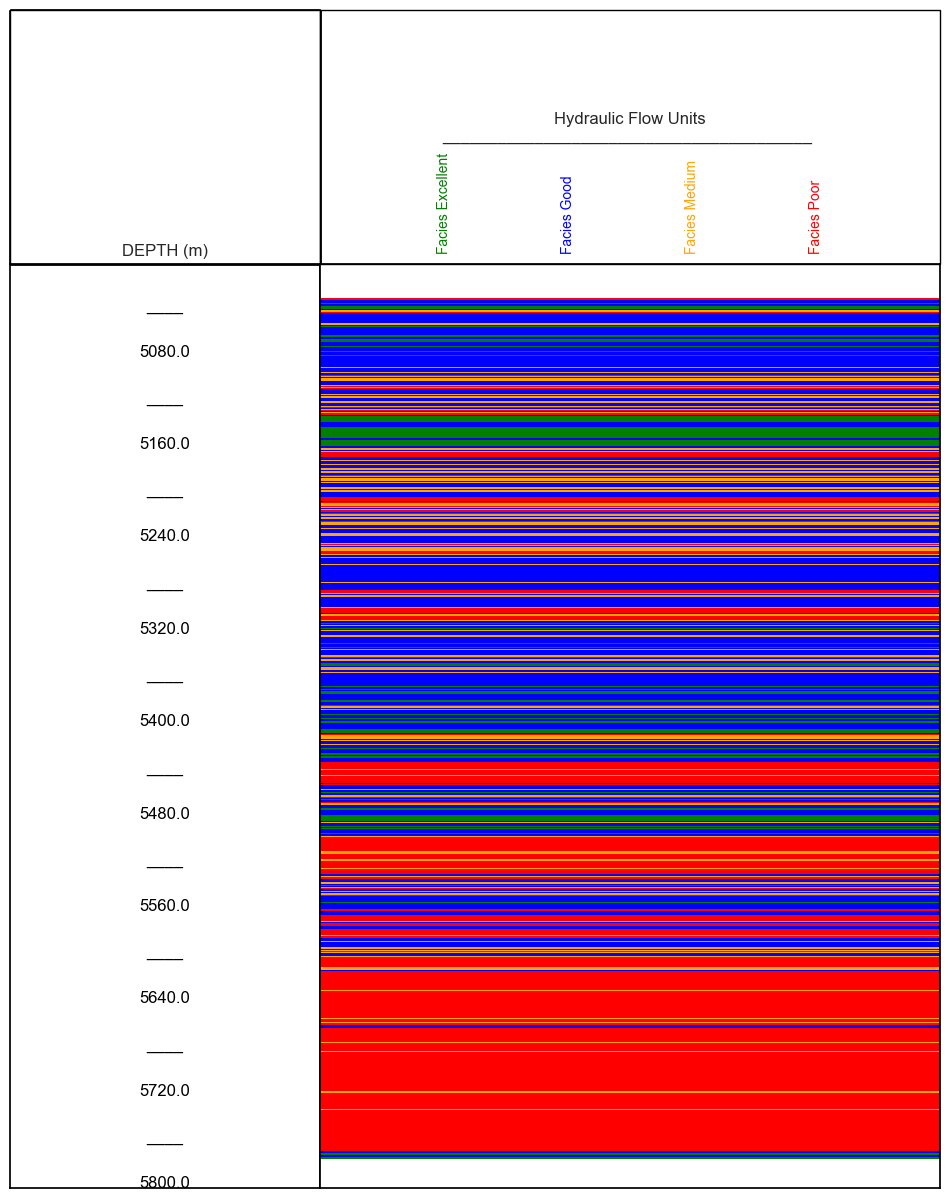

In [ ]:
colors = ['red', 'orange' ,'green', 'blue']

plot1 = ['facies', rock1045.attr, 'HFU', rock1045.attr.index.values, 1, colors, 'Hydraulic Flow Units']


plots = [plot1]

plotting.logView(plots, 2, (12, 12), 12, [5000, 5800])

Now we can save the RockLog into a .rock file for future analysis.

In [ ]:
#rock1045.saveRockLog('../../Dataset/1-BRSA-1045-SPS/rocklog1045.rock')

### Hugo - alteração a partir daqui

In [ ]:
# Test #2: Extracting LAS input data of sample F7289H at depth (5055.1 m)
# Using data from well log profile processed with pyrockphys

sample_depth = 5055.1

depths = rock1045.attr.index.to_numpy(dtype=float)
idx = int(np.argmin(np.abs(depths - sample_depth)))

sample_log = rock1045.attr.iloc[idx]

# Velocidade P do perfil (km/s)
vp_m = sample_log['vp']

# Porosidade total
phi = sample_log['PHIT']

# Frações de poros (normalizar para somar 1)
f_macro_abs = sample_log['MACROPORE']
f_meso_abs = sample_log['MESOPORE']
f_micro_abs = sample_log['MICROPORE']

total_poros = f_macro_abs + f_meso_abs + f_micro_abs
f_macro = f_macro_abs / total_poros
f_meso = f_meso_abs / total_poros
f_micro = f_micro_abs / total_poros

frac_inc_known = [f_macro, f_meso]
fmic = f_micro

# Propriedades da matriz (GPa)
# valores retirados do excel dentro da pasta input_data/input_multiscale_lab_data_dry_22MPa_BRSA_1045
# tentei usar os valores dela biblioteca Pyrockphys, mas estavam muitos diferentes 
# dos dados do excel.
# k1 = sample_log['kr_lime']   
# mu1 = sample_log['mr_lime']  
# ro1 = sample_log['den_lime'] 

k1 = 68.00
mu1 = 32.58
ro1 = 2.719

# Dry (air)
k2 = 0.000131
mu2 = 0.0
ro2 = 0.00119

# Aspect ratios vindos do microCT
asp_inc_known = [0.56, 0.58]

# calling method
vpa_out, vsa_out, rho_out, aspmic_out, fit_out = arinc.aspect_ratio_Image_dem_multiscale(
    vp_m, k1, mu1, ro1,
    k2, mu2, ro2,
    phi,
    frac_inc_known,
    asp_inc_known,
    fmic
)

print("--------------------------------------------------")
print("RESULTADOS DA INVERSÃO DEM MULTISCALE - Test #2")
print("--------------------------------------------------")
print(f"Vp Medida: {vp_m:.4f} km/s")
print(f"Razão de Aspecto Invertida (P3 - aspmic): {aspmic_out:.4f}")
print(f"Vp Calculada (Vp_a): {vpa_out:.4f} km/s")
print(f"Taxa de Ajuste (fit): {fit_out:.2f}%")
print("--------------------------------------------------")

--------------------------------------------------
RESULTADOS DA INVERSÃO DEM MULTISCALE - Test #2
--------------------------------------------------
Vp Medida: 4.6047 km/s
Razão de Aspecto Invertida (P3 - aspmic): 0.0480
Vp Calculada (Vp_a): 4.5936 km/s
Taxa de Ajuste (fit): 1.00%
--------------------------------------------------
